# **Problem Statement**

## **Business Context**

Workplace safety in hazardous environments like construction sites and industrial plants is crucial to prevent accidents and injuries. One of the most important safety measures is ensuring workers wear safety helmets, which protect against head injuries from falling objects and machinery. Non-compliance with helmet regulations increases the risk of serious injuries or fatalities, making effective monitoring essential, especially in large-scale operations where manual oversight is prone to errors and inefficiency.

To overcome these challenges, SafeGuard Corp plans to develop an automated image analysis system capable of detecting whether workers are wearing safety helmets. This system will improve safety enforcement, ensuring compliance and reducing the risk of head injuries. By automating helmet monitoring, SafeGuard aims to enhance efficiency, scalability, and accuracy, ultimately fostering a safer work environment while minimizing human error in safety oversight.

## **Objective**

As a data scientist at SafeGuard Corp, you are tasked with developing an image classification model that classifies images into one of two categories:
- **With Helmet:** Workers wearing safety helmets.
- **Without Helmet:** Workers not wearing safety helmets.

## **Data Description**

The dataset consists of **4125 images**, divided into two categories:

- **With Helmet:** 3161 images showing workers wearing helmets.
- **Without Helmet:** 964 images showing workers not wearing helmets.

**Dataset Characteristics:**
- **Variations in Conditions:** Images include diverse environments such as construction sites, factories, and industrial settings, with variations in lighting, angles, and worker postures to simulate real-world conditions.
- **Worker Activities:** Workers are depicted in different actions such as standing, using tools, or moving, ensuring robust model learning for various scenarios.

# **Installing and Importing the Necessary Libraries**

In [ ]:
!pip install tensorflow[and-cuda] scikit-learn==1.6.1 opencv-python==4.12.0.88 seaborn==0.13.2 matplotlib==3.10.0 numpy==2.0.2 pandas==2.2.3 -q

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Installing backend dependencies ... done
  Preparing metadata (pyproject.toml) ... canceled
ERROR: Operation cancelled by user


KeyboardInterrupt: 

**Note:**

- After running the above cell, kindly restart the notebook kernel (for Jupyter Notebook) or runtime (for Google Colab) and run all cells sequentially from the next cell.

- On executing the above line of code, you might see a warning regarding package dependencies. This error message can be ignored as the above code ensures that all necessary libraries and their dependencies are maintained to successfully execute the code in this notebook.

In [ ]:
import os
import random
import numpy as np                                                                               # Importing numpy for Matrix Operations
import pandas as pd
import seaborn as sns
import matplotlib.image as mpimg                                                                              # Importing pandas to read CSV files
import matplotlib.pyplot as plt                                                                  # Importting matplotlib for Plotting and visualizing images
import math                                                                                      # Importing math module to perform mathematical operations
import cv2


# Tensorflow modules
import keras
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator                              # Importing the ImageDataGenerator for data augmentation
from tensorflow.keras.models import Sequential                                                   # Importing the sequential module to define a sequential model
from tensorflow.keras.layers import Dense,Dropout,Flatten,Conv2D,MaxPooling2D,BatchNormalization # Defining all the layers to build our CNN Model
from tensorflow.keras.optimizers import Adam,SGD                                                 # Importing the optimizers which can be used in our model
from sklearn import preprocessing                                                                # Importing the preprocessing module to preprocess the data
from sklearn.model_selection import train_test_split                                             # Importing train_test_split function to split the data into train and test
from sklearn.metrics import confusion_matrix
from tensorflow.keras.models import Model
from keras.applications.vgg16 import VGG16                                               # Importing confusion_matrix to plot the confusion matrix

# Display images using OpenCV
from google.colab.patches import cv2_imshow

#Imports functions for evaluating the performance of machine learning models
from sklearn.metrics import confusion_matrix, f1_score,accuracy_score, recall_score, precision_score, classification_report
from sklearn.metrics import mean_squared_error as mse                                                 # Importing cv2_imshow from google.patches to display images

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

In [ ]:
print("Num GPUs Available:", len(tf.config.list_physical_devices('GPU')))
print(tf.__version__)

Num GPUs Available: 1
2.20.0


In [ ]:
# 1. Set Python random seed
random.seed(42)

# 2. Set NumPy random seed
np.random.seed(42)

# 3. Set TensorFlow seed (covers Keras + backend)
tf.keras.utils.set_random_seed(42)

# 4. Enable deterministic GPU ops (if using GPU)
tf.config.experimental.enable_op_determinism()

# **Data Overview**


##Loading the data

In [ ]:
# uncomment and run the below code snippets if the dataset is present in the Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
filepath = '/content/drive/My Drive/AIML/UT Austin PGP/CNN-Comupter Vision/Project/'

In [ ]:
# Load the image file of the dataset
images = np.load(filepath+'images.npy')

# Load the labels file of the dataset
labels = pd.read_csv(filepath+'labels.csv')

This cell loads the images from the specified path into a NumPy array and the labels from the specified CSV file into a pandas DataFrame.

In [ ]:
print(images.shape)
print(labels.shape)

(4125, 200, 200, 3)
(4125, 1)


Summary of data set: There are 4125 RGB images of shape 200 x 200, each image having 3 channels - which means RGB.



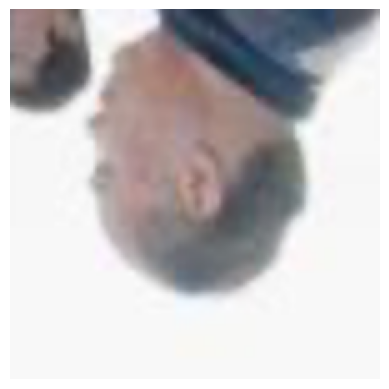

In [ ]:
plt.imshow(images[random.randrange(len(images))])
plt.axis('off');

Just being curious to see any random image ☺

# **Exploratory Data Analysis**

###Plot random images from each of the classes and print their corresponding labels.

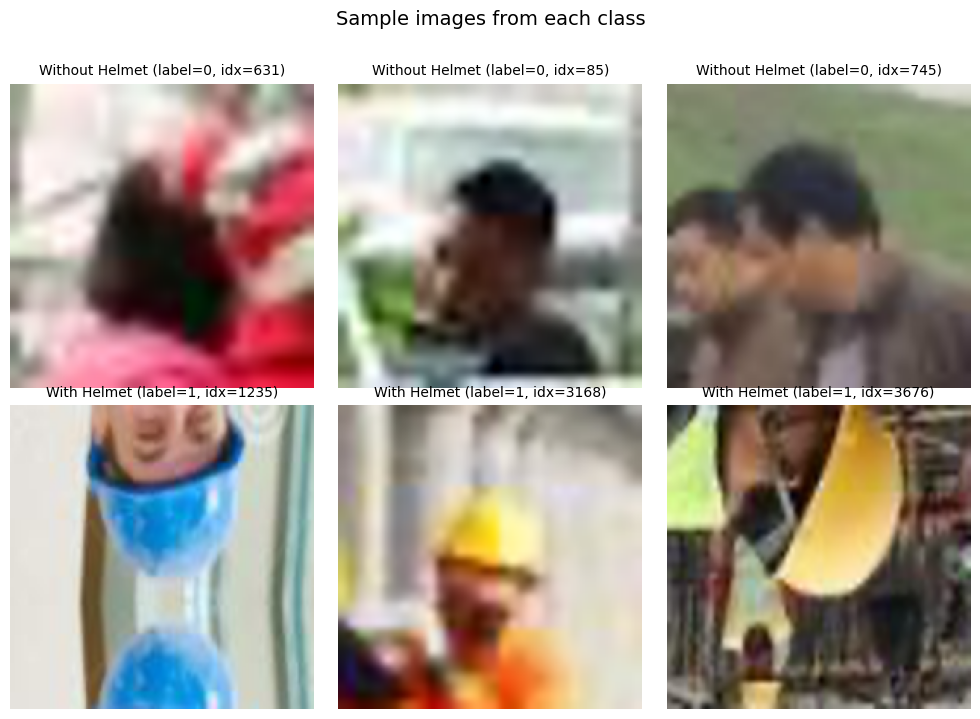

In [ ]:
# Plot 3 random images per class with their labels
class_names = {0: "Without Helmet", 1: "With Helmet"}
rng = np.random.default_rng(42)

fig, axes = plt.subplots(2, 3, figsize=(10, 7))
for cls in [0, 1]:
    class_idxs = np.where(labels["label"].values == cls)[0]
    sample_idxs = rng.choice(class_idxs, size=3, replace=False)
    for j, idx in enumerate(sample_idxs):
        ax = axes[cls, j]
        ax.imshow(images[idx])
        ax.set_title(f"{class_names[cls]} (label={cls}, idx={idx})", fontsize=10)
        ax.axis("off")
plt.suptitle("Sample images from each class", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

This cell displays 6 sample images, first 3 showing workers with helmet and next 3 workers without helmet, illustrating the two classes in the dataset. The output shows the plots of these images, confirming that the code successfully selected and displayed representative images from each category.

## Checking for class imbalance


Class distribution:
  label=0 (Without Helmet ):  964  ( 23.4%)
  label=1 (With Helmet    ): 3161  ( 76.6%)


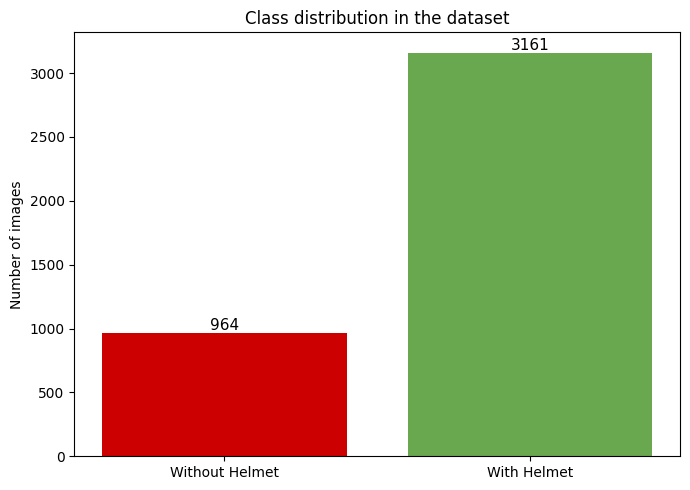


Imbalance ratio: 3.28 : 1 (With Helmet : Without Helmet)
The majority class (With Helmet) is ~3.3x larger than the minority class.
We will address this via class weights during training.


In [ ]:
# Class imbalance check
class_counts = labels["label"].value_counts().sort_index()

print("Class distribution:")
for cls, count in class_counts.items():
    prcntge = count / len(labels) * 100
    print(f"  label={cls} ({class_names[cls]:<15s}): {count:>4d}  ({prcntge:5.1f}%)")

# Bar plot
fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(
    [class_names[i] for i in class_counts.index],
    class_counts.values,
    color=["#cc0000", "#6aa84f"],
)
for bar, count in zip(bars, class_counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
            str(count), ha="center", va="bottom", fontsize=11)
ax.set_ylabel("Number of images")
ax.set_title("Class distribution in the dataset")
plt.tight_layout()
plt.show()

imbalance_ratio = class_counts.max() / class_counts.min()
print(f"\nImbalance ratio: {imbalance_ratio:.2f} : 1 ({class_names[class_counts.idxmax()]} : {class_names[class_counts.idxmin()]})")
print("The majority class (With Helmet) is ~3.3x larger than the minority class.")
print("We will address this via class weights during training.")

This cell generates a bar plot visualizing the distribution of images across the two class labels ("Without Helmet" and "With Helmet"). The plot shows that there are 964 images in the "Without Helmet" class and 3161 images in the "With Helmet" class. This indicates a relatively balanced dataset, which is important for training unbiased classification models.

# **Data Preprocessing**

### Splitting the dataset



In [ ]:
# Stratified 70 / 15 / 15 split (train / val / test) — fixed seed for reproducibility
X = images
y = labels["label"].values

#Split the entire dataset into train and temp into 70:30 ratio
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3,stratify=y, random_state=42)

#Split the temp dataset into validation and test into 50:50 ratio
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5,stratify=y_temp, random_state=42)

print(f"Train : X={X_train.shape}, labels (0/1) = {np.bincount(y_train).tolist()}")
print(f"Val   : X={X_val.shape}, labels (0/1) = {np.bincount(y_val).tolist()}")
print(f"Test  : X={X_test.shape}, labels (0/1) = {np.bincount(y_test).tolist()}")
print()
for name, y_part in [("train", y_train), ("val", y_val), ("test", y_test)]:
    ratio = (y_part == 1).mean()
    print(f"  {name:<5s} With-Helmet ratio: {ratio:.3f}")

# Wrap targets as DataFrames so the utility functions (which call .to_numpy().reshape(-1)) work
y_train = pd.DataFrame(y_train, columns=["label"])
y_val = pd.DataFrame(y_val, columns=["label"])
y_test = pd.DataFrame(y_test, columns=["label"])


Train : X=(2887, 200, 200, 3), labels (0/1) = [675, 2212]
Val   : X=(619, 200, 200, 3), labels (0/1) = [144, 475]
Test  : X=(619, 200, 200, 3), labels (0/1) = [145, 474]

  train With-Helmet ratio: 0.766
  val   With-Helmet ratio: 0.767
  test  With-Helmet ratio: 0.766


The output above shows the shapes of the training, validation, and test sets after splitting the data.

* The training set has **2887** images where Without helmet = **675**, with helmet = **2212**, each with dimensions 200x200 pixels and 3 color channels (RGB), and the corresponding labels.
* The validation set has **619** images where Without helmet = **144**, with helmet = **475**, and labels with the same dimensions.
* The test set has **619** images where Without helmet = **145**, with helmet = **474**, and labels with the same dimensions.
The data has been successfully split into the specified proportions (**70%** train, **15%** validation, **15%** test).

### Data Normalization

Since the image pixel values range from 0-255, our method of normalization here will be scaling - we shall divide all the pixel values by 255 to standardize the images to have values between 0-1.

In [ ]:
# Scale pixels from [0, 255] uint8 → [0, 1] float32
X_train = X_train.astype("float32") / 255.0
X_val   = X_val.astype("float32")   / 255.0
X_test  = X_test.astype("float32")  / 255.0

print(f"Normalized range: [{X_train.min():.3f}, {X_train.max():.3f}]")
print(f"Train dtype    : {X_train.dtype}")

# Compute class weights from the TRAIN split only (avoid test leakage)
from sklearn.utils.class_weight import compute_class_weight
y_train_arr = y_train.values.ravel()
cw = compute_class_weight("balanced", classes=np.array([0, 1]), y=y_train_arr)
class_weight_dict = {0: float(cw[0]), 1: float(cw[1])}
print(f"\nBalanced class weights (train-split only): {class_weight_dict}")

Normalized range: [0.000, 1.000]
Train dtype    : float32

Balanced class weights (train-split only): {0: 2.1385185185185187, 1: 0.6525768535262206}


Since most of the images are not in great quality and for helmet detection, RGB may contain useful information, such as

* helmet color
* clothing color
* skin/background differences
* reflective helmets
* environmental context

So in my opinion, converting from RGB to grayscale wouldn't be a great idea for this particular case.

# **Model Building**

##Model Evaluation Criterion

## Utility Functions

In [ ]:
# defining a function to compute different metrics to check performance of a classification model built using statsmodels
def model_performance_classification(model, predictors, target):
    """
    Function to compute different metrics to check classification model performance

    model: classifier
    predictors: independent variables
    target: dependent variable
    """

    # checking which probabilities are greater than threshold
    pred = model.predict(predictors).reshape(-1)>0.5

    target = target.to_numpy().reshape(-1)


    acc = accuracy_score(target, pred)  # to compute Accuracy
    recall = recall_score(target, pred, average='micro')  # to compute Recall
    precision = precision_score(target, pred, average='micro')  # to compute Precision
    f1 = f1_score(target, pred, average='micro')  # to compute F1-score

    # creating a dataframe of metrics
    df_perf = pd.DataFrame({"Accuracy": acc, "Recall": recall, "Precision": precision, "F1 Score": f1,},index=[0],)

    return df_perf

In [ ]:
def plot_confusion_matrix(model,predictors,target,ml=False):
    """
    Function to plot the confusion matrix

    model: classifier
    predictors: independent variables
    target: dependent variable
    ml: To specify if the model used is an sklearn ML model or not (True means ML model)
    """

    # checking which probabilities are greater than threshold
    pred = model.predict(predictors).reshape(-1)>0.5

    target = target.to_numpy().reshape(-1)

    # Plotting the Confusion Matrix using confusion matrix() function which is also predefined tensorflow module
    confusion_matrix = tf.math.confusion_matrix(target,pred)
    f, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(
        confusion_matrix,
        annot=True,
        linewidths=.4,
        fmt="d",
        square=True,
        ax=ax
    )
    plt.show()

##Model 1: Convolutional Neural Network (CNN) from Scratch

Let's build a CNN Model.

The model has 2 main parts:

* The Feature Extraction layers which are comprised of convolutional and pooling layers.
* The Fully Connected classification layers for prediction.

In [ ]:
# Model 1: a small CNN built from scratch
tf.keras.backend.clear_session()

# Initialize a sequential model, which is a linear stack of layers.
model1 = Sequential([
    Conv2D(32, (3, 3), activation="relu", input_shape=(200, 200, 3)),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    Conv2D(64, (3, 3), activation="relu"),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    Conv2D(128, (3, 3), activation="relu"),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    Flatten(),
    Dense(128, activation="relu"),
    Dropout(0.3),
    Dense(1, activation="sigmoid"),
], name="cnn_from_scratch")

# Define the optimizer for the model.
# Using the Adam optimizer with a learning rate of 0.001.
opt = Adam(learning_rate=1e-4)

# Compile the model.
# Specify the optimizer, the loss function (binary crossentropy for binary classification),
# and the metrics to monitor during training (accuracy and recall).
model1.compile(optimizer=opt, loss='binary_crossentropy', metrics=["accuracy","recall"])

# Display the model summary.
# This shows the layers of the model, their output shapes, and the number of parameters in each layer.
print(model1.summary())

#Train the model using X_train and y_train and validate using data sets X_val, y_val)
history1 = model1.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=32,
    class_weight=class_weight_dict,
    verbose=1)

Model: "cnn_from_scratch"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 198, 198, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 198, 198, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 99, 99, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 97, 97, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 97, 97, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 48, 48, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 46, 46, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 46, 46, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 23, 23, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 21, 21, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 21, 21, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 10, 10, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12800)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,638,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,880,897 (7.18 MB)

 Trainable params: 1,880,193 (7.17 MB)

 Non-trainable params: 704 (2.75 KB)

None
Epoch 1/10
91/91 ━━━━━━━━━━━━━━━━━━━━ 21s 132ms/step - accuracy: 0.8691 - loss: 0.3468 - recall: 0.8684 - val_accuracy: 0.2326 - val_loss: 2.0151 - val_recall: 0.0000e+00
Epoch 2/10
91/91 ━━━━━━━━━━━━━━━━━━━━ 10s 105ms/step - accuracy: 0.9418 - loss: 0.1499 - recall: 0.9376 - val_accuracy: 0.2326 - val_loss: 2.4235 - val_recall: 0.0000e+00
Epoch 3/10
91/91 ━━━━━━━━━━━━━━━━━━━━ 9s 104ms/step - accuracy: 0.9706 - loss: 0.0766 - recall: 0.9652 - val_accuracy: 0.5040 - val_loss: 1.1217 - val_recall: 0.3558
Epoch 4/10
91/91 ━━━━━━━━━━━━━━━━━━━━ 10s 107ms/step - accuracy: 0.9799 - loss: 0.0513 - recall: 0.9778 - val_accuracy: 0.8271 - val_loss: 0.4271 - val_recall: 0.8042
Epoch 5/10
91/91 ━━━━━━━━━━━━━━━━━━━━ 10s 114ms/step - accuracy: 0.9896 - loss: 0.0349 - recall: 0.9882 - val_accuracy: 0.8885 - val_loss: 0.3103 - val_recall: 0.9200
Epoch 6/10
91/91 ━━━━━━━━━━━━━━━━━━━━ 10s 107ms/step - accuracy: 0.9913 - loss: 0.0256 - recall: 0.9901 - val_accuracy: 0.8998 - val_loss: 0.2610 - val_r

Not much significant change after 3rd epoch. Let's check this in graphical representation below:

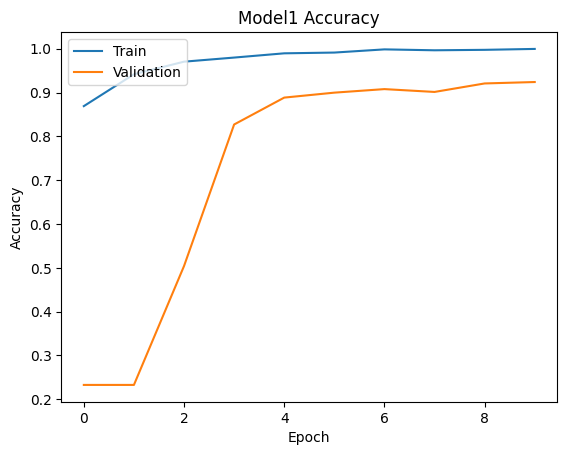

In [ ]:
# Plot the training accuracy over epochs from the history object.
plt.plot(history1.history['accuracy'])
# Plot the validation accuracy over epochs from the history object.
plt.plot(history1.history['val_accuracy'])

# Set the title of the plot.
plt.title('Model1 Accuracy')

# Set the label for the y-axis.
plt.ylabel('Accuracy')

# Set the label for the x-axis.
plt.xlabel('Epoch')

# Add a legend to the plot to identify the training and validation lines.
plt.legend(['Train', 'Validation'], loc='upper left')

# Display the generated plot.
plt.show()

91/91 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step
Model 1 Training Performance:
   Accuracy    Recall  Precision  F1 Score
0  0.999307  0.999307   0.999307  0.999307
Model 1 Training Confusion Matrix:
91/91 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step


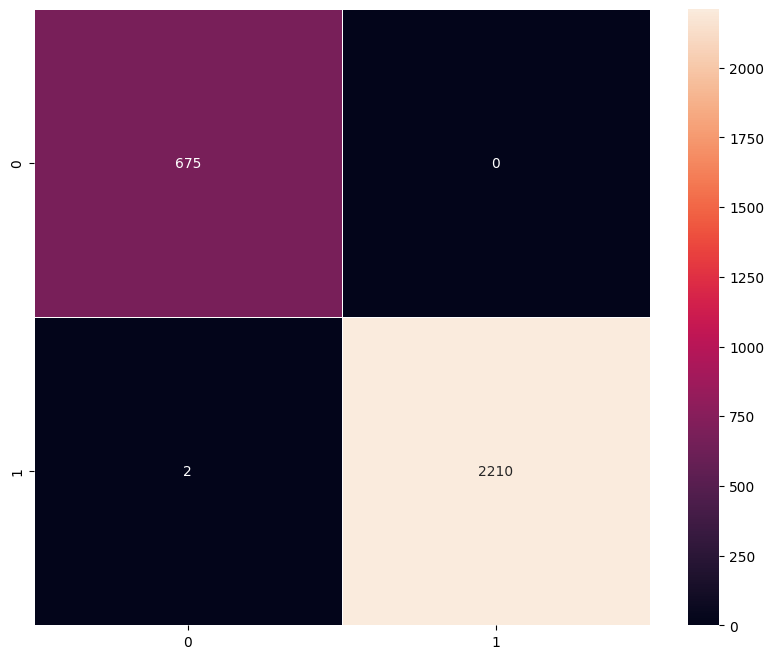

In [ ]:
# Evaluate the model on the Training set
model1_train_performance = model_performance_classification(model1, X_train, y_train)
print("Model 1 Training Performance:")
print(model1_train_performance)

# Plot the confusion matrix for the Training set
print("Model 1 Training Confusion Matrix:")
plot_confusion_matrix(model1, X_train, y_train)

20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step
Model 1 Validation Performance:
   Accuracy    Recall  Precision  F1 Score
0  0.924071  0.924071   0.924071  0.924071
Model 1 Validation Confusion Matrix:
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step


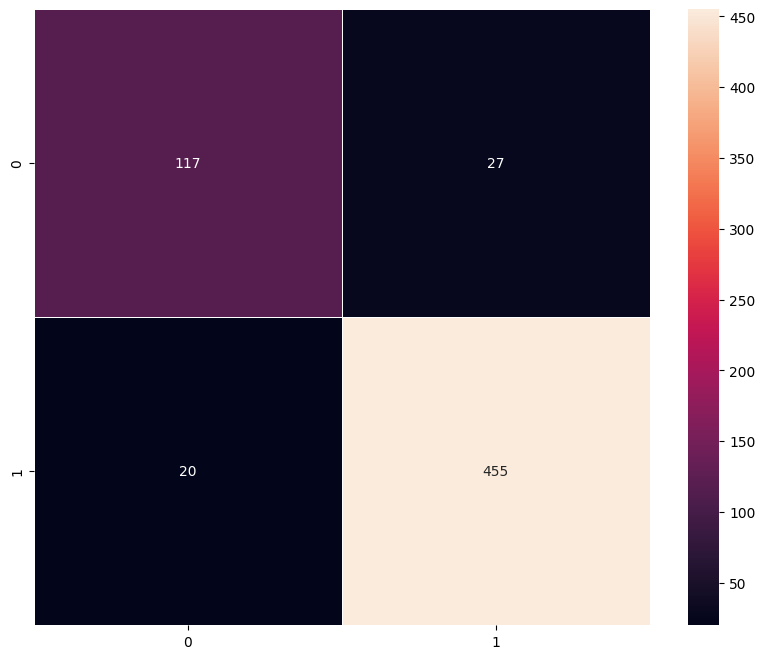

In [ ]:
# Evaluate the model on the validation set
model1_val_performance = model_performance_classification(model1, X_val, y_val)
print("Model 1 Validation Performance:")
print(model1_val_performance)

# Plot the confusion matrix for the validation set
print("Model 1 Validation Confusion Matrix:")
plot_confusion_matrix(model1, X_val, y_val)

* Images were classified accurately for class 1(with helmet) and all images were classified in accurately for class 1(with helmet).
* The model is performing better with training set than validation set, sensing some overfitting.

### Visualizing the predictions

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step


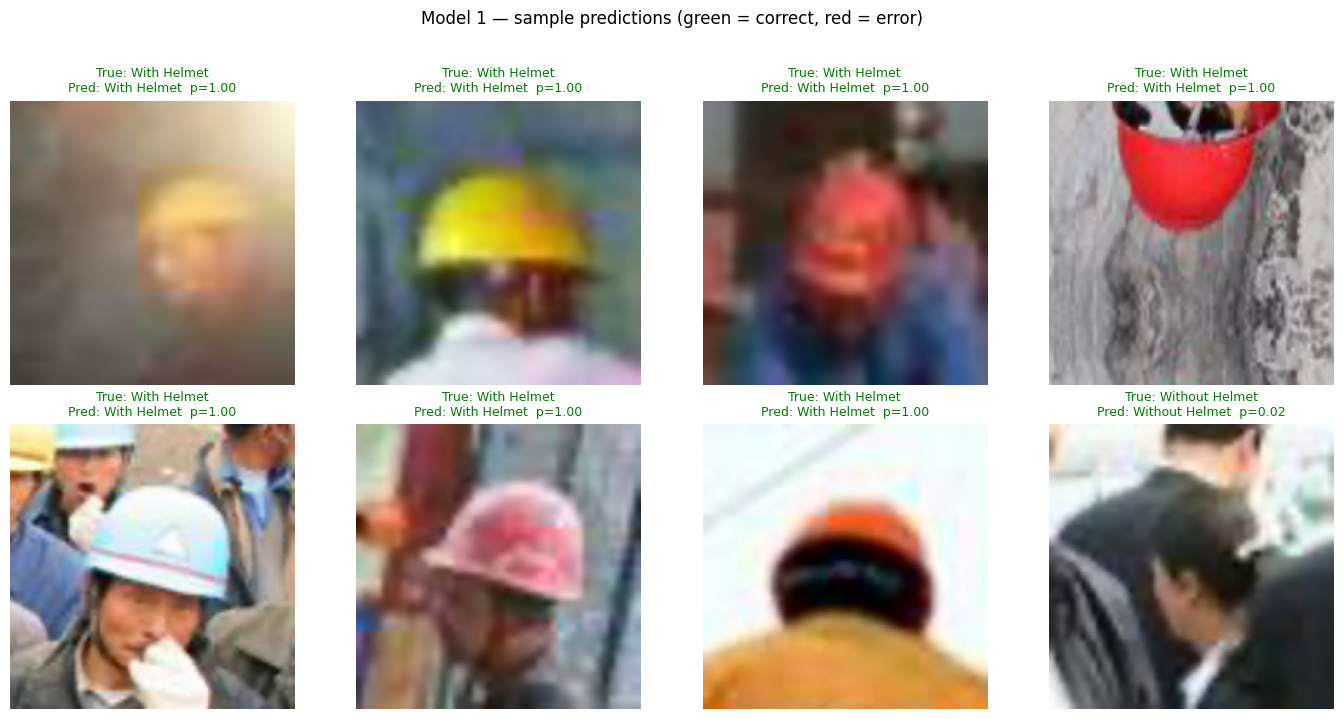

In [ ]:
# Visualize Model 1's predictions on a random sample of validation images
rng = np.random.default_rng(42)
sample_idx = rng.choice(len(X_val), size=8, replace=False)
sample_probs = model1.predict(X_val[sample_idx]).ravel()
sample_preds = (sample_probs > 0.5).astype(int)
sample_true  = y_val.values.ravel()[sample_idx]

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for ax, i, prob, pred, true in zip(axes.ravel(), sample_idx, sample_probs, sample_preds, sample_true):
    ax.imshow(X_val[i])
    correct = pred == true
    color = "green" if correct else "red"
    ax.set_title(
        f"True: {class_names[true]}\nPred: {class_names[pred]}  p={prob:.2f}",
        fontsize=9, color=color,
    )
    ax.axis("off")
plt.suptitle("Model 1 — sample predictions (green = correct, red = error)", y=1.02)
plt.tight_layout(); plt.show()


This cell visualizes 8 sample images from the validation set and displays the model's prediction along with the true label for each. The output shows that the model has correctly predicted "With Helmet" (Label 1) with probability 1, and when the true label was "Without Helmet" (Label 0), model's prediction is correct. This provides a visual check of the model's performance on individual examples.

## Model 2: Transfer Learning with VGG-16 (Base)

* We will be loading a pre-built architecture - VGG16, which was trained on the ImageNet dataset and is the runner-up in the ImageNet competition in 2014.

* For training VGG16, we will directly use the convolutional and pooling layers and freeze their weights i.e. no training will be done on them. For classification, we will add a Flatten and a single dense layer.

In [ ]:
# Model 2: transfer learning from VGG-16 with a minimal head (flatten → dense)
tf.keras.backend.clear_session()

# Import the VGG16 model
base_model_2 = VGG16(
    weights="imagenet", include_top=False, input_shape=(200, 200, 3),
)

# freeze the convolutional base
base_model_2.trainable = False

# Create a new Sequential model (model2)
model2 = Sequential([
    base_model_2,
    Flatten(),
    Dense(1, activation="sigmoid"),
], name="vgg16_base_minimal_head")

# Compile model2
model2.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss="binary_crossentropy",
    metrics=["accuracy"],
)

# Print the summary of model2
print(model2.summary())

# Train model2
history2 = model2.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=32,
    class_weight=class_weight_dict,
    verbose=1
)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "vgg16_base_minimal_head"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 6, 6, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │        18,433 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,733,121 (56.20 MB)

 Trainable params: 18,433 (72.00 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

None
Epoch 1/10
91/91 ━━━━━━━━━━━━━━━━━━━━ 17s 169ms/step - accuracy: 0.6439 - loss: 0.6138 - val_accuracy: 0.7205 - val_loss: 0.5313
Epoch 2/10
91/91 ━━━━━━━━━━━━━━━━━━━━ 15s 165ms/step - accuracy: 0.7600 - loss: 0.4865 - val_accuracy: 0.7932 - val_loss: 0.4633
Epoch 3/10
91/91 ━━━━━━━━━━━━━━━━━━━━ 16s 172ms/step - accuracy: 0.8133 - loss: 0.4262 - val_accuracy: 0.8207 - val_loss: 0.4213
Epoch 4/10
91/91 ━━━━━━━━━━━━━━━━━━━━ 15s 164ms/step - accuracy: 0.8362 - loss: 0.3875 - val_accuracy: 0.8336 - val_loss: 0.3933
Epoch 5/10
91/91 ━━━━━━━━━━━━━━━━━━━━ 14s 158ms/step - accuracy: 0.8493 - loss: 0.3596 - val_accuracy: 0.8368 - val_loss: 0.3731
Epoch 6/10
91/91 ━━━━━━━━━━━━━━━━━━━━ 14s 155ms/step - accuracy: 0.8614 - loss: 0.3380 - val_accuracy: 0.8481 - val_loss: 0.3579
Epoch 7/10
91/91 ━━━━━━━━━━━━━━━━━━━━ 17s 187ms/step - accuracy: 0.8691 - loss: 0.3204 - val_accuracy: 0.8498 - val_loss: 0.3459
Epoch 8/10
91/91 ━━━━━━━━━━━━━━━━━━━━ 15s 161ms/step - accuracy: 0.8739 - loss: 0.3056 - val

Not much significant change after 3rd epoch. Let's check this in graphical representation below:

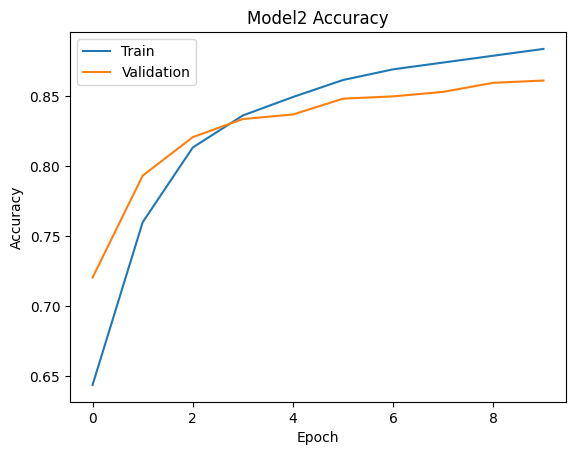

In [ ]:
# Plot the training accuracy over epochs from the history object.
plt.plot(history2.history['accuracy'])
# Plot the validation accuracy over epochs from the history object.
plt.plot(history2.history['val_accuracy'])

# Set the title of the plot.
plt.title('Model2 Accuracy')

# Set the label for the y-axis.
plt.ylabel('Accuracy')

# Set the label for the x-axis.
plt.xlabel('Epoch')

# Add a legend to the plot to identify the training and validation lines.
plt.legend(['Train', 'Validation'], loc='upper left')

# Display the generated plot.
plt.show()

91/91 ━━━━━━━━━━━━━━━━━━━━ 13s 131ms/step
Model 2 Training Performance:
   Accuracy    Recall  Precision  F1 Score
0  0.893315  0.893315   0.893315  0.893315
Model 2 Training Confusion Matrix:
91/91 ━━━━━━━━━━━━━━━━━━━━ 13s 130ms/step


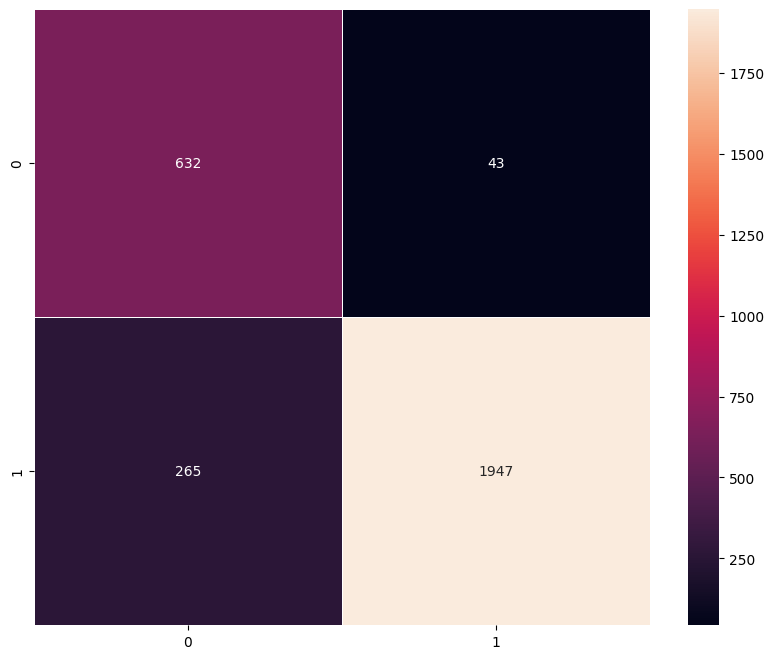

In [ ]:
# Evaluate the model on the Training set
model2_train_performance = model_performance_classification(model2, X_train, y_train)
print("Model 2 Training Performance:")
print(model2_train_performance)

# Plot the confusion matrix for the Training set
print("Model 2 Training Confusion Matrix:")
plot_confusion_matrix(model2, X_train, y_train)

Model couldn't correctly identify 265 cases of with helmet, and considered them as without helmet. Though model's identification on without helmet is much better. Let's look at the model's prediction on validation set below:

20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 130ms/step
Model 2 Validation Performance:
   Accuracy    Recall  Precision  F1 Score
0  0.861066  0.861066   0.861066  0.861066
Model 2 Validation Confusion Matrix:
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 130ms/step


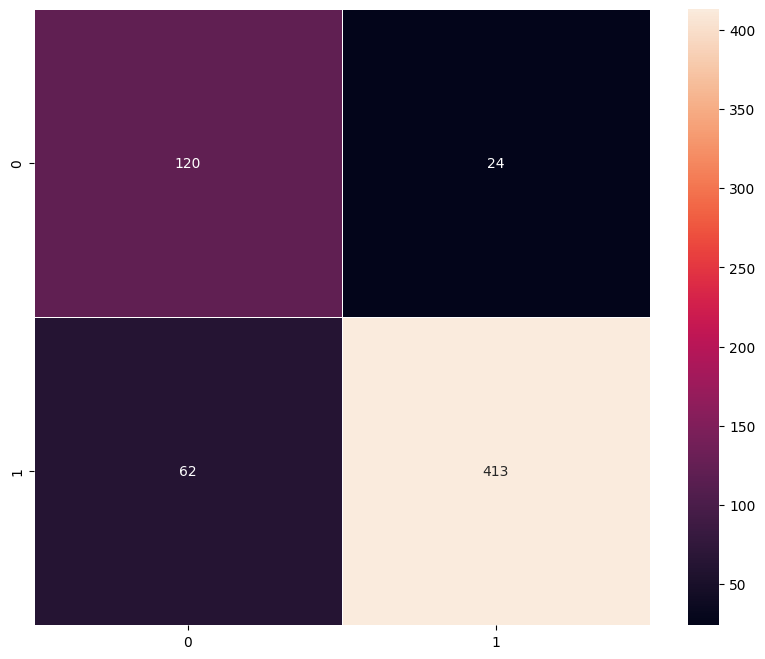

In [ ]:
# Evaluate the model on the validation set
model2_val_performance = model_performance_classification(model2, X_val, y_val)
print("Model 2 Validation Performance:")
print(model2_val_performance)

# Plot the confusion matrix for the validation set
print("Model 2 Validation Confusion Matrix:")
plot_confusion_matrix(model2, X_val, y_val)

Model's prediction on 'with helmet' is similar wrt training set, but model clearly outperforms on 'without helmet' on the training set. Still seeing overfitting, needs to add dropout in next model.

Previous model's overfitting issue is reduced though

### Visualizing the predictions

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step


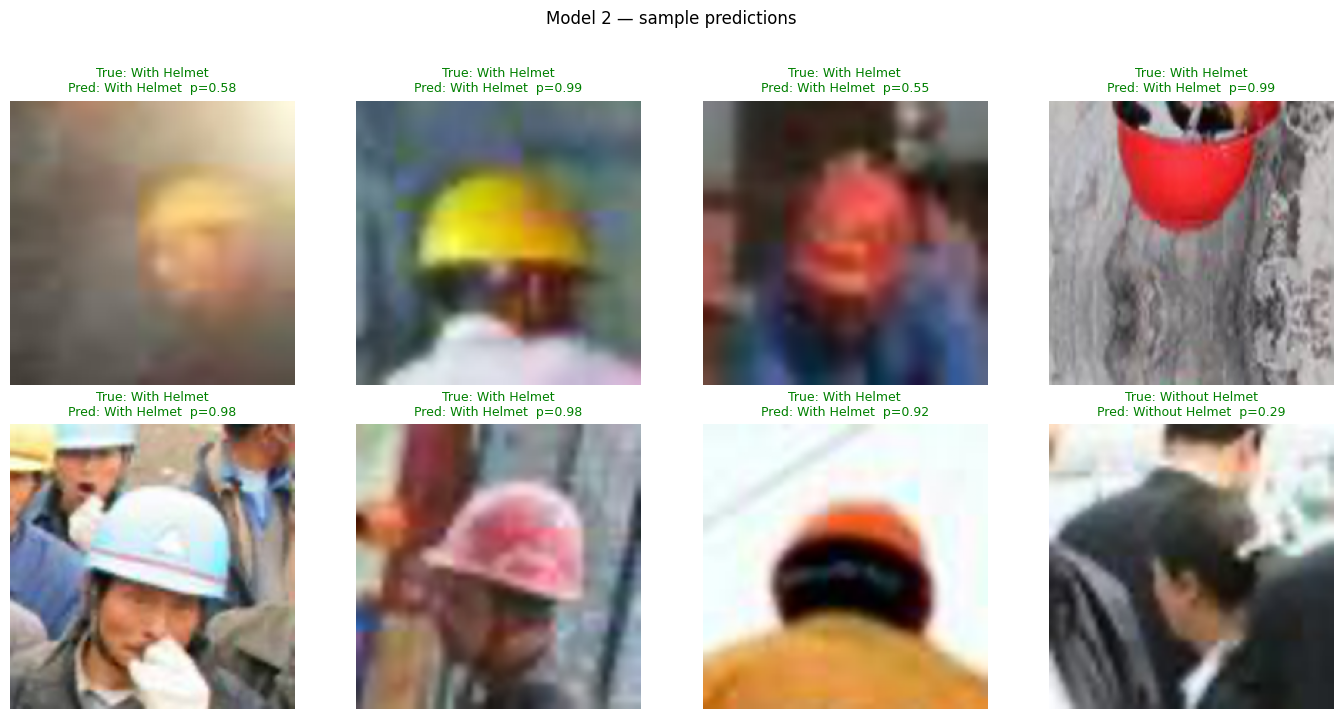

In [ ]:
# Visualize Model 2's predictions
rng = np.random.default_rng(42)
sample_idx = rng.choice(len(X_val), size=8, replace=False)
sample_probs = model2.predict(X_val[sample_idx]).ravel()
sample_preds = (sample_probs > 0.5).astype(int)
sample_true  = y_val.values.ravel()[sample_idx]

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for ax, i, prob, pred, true in zip(axes.ravel(), sample_idx, sample_probs, sample_preds, sample_true):
    ax.imshow(X_val[i])
    color = "green" if pred == true else "red"
    ax.set_title(
        f"True: {class_names[true]}\nPred: {class_names[pred]}  p={prob:.2f}",
        fontsize=9, color=color,
    )
    ax.axis("off")
plt.suptitle("Model 2 — sample predictions", y=1.02)
plt.tight_layout(); plt.show()


This visulization of 8 images clearly reflects the model's validation performance score.
* Model predict false negetive for the first image of 'with helmet' as 'without helmet'
* Model's correctly predicts 'without helmet' here.
* Model correctly predicts other 'with helmet' images with high probability.

## Model 3: Transfer Learning with VGG-16 (Base + FFNN)





In [ ]:
# Model 3: VGG-16 base + a deeper FFNN head
tf.keras.backend.clear_session()

# Create a fresh VGG16 base model for fine-tuning
base_model_3 = VGG16(
    weights="imagenet", include_top=False, input_shape=(200, 200, 3),
)

# Unfreeze the base model completely initially
base_model_3.trainable = False

# Build the new model (model3) by adding the classification head on top of the fine-tuned base model
model3 = Sequential([
    base_model_3,
    Flatten(),
    Dense(256, activation="relu"),
    Dropout(0.3),
    Dense(128, activation="relu"),
    Dropout(0.2),
    Dense(1, activation="sigmoid"),
], name="vgg16_base_plus_ffnn")

# Compile model3 with a very low learning rate for fine-tuning
model3.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss="binary_crossentropy",
    metrics=["accuracy"],
)

# Print the summary of model3
print(model3.summary())

# Train model3
history3 = model3.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=32,
    class_weight=class_weight_dict,
    verbose=1
)

Model: "vgg16_base_plus_ffnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 6, 6, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     4,718,848 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,466,561 (74.26 MB)

 Trainable params: 4,751,873 (18.13 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

None
Epoch 1/10
91/91 ━━━━━━━━━━━━━━━━━━━━ 19s 178ms/step - accuracy: 0.7115 - loss: 0.5449 - val_accuracy: 0.7189 - val_loss: 0.5251
Epoch 2/10
91/91 ━━━━━━━━━━━━━━━━━━━━ 16s 171ms/step - accuracy: 0.8327 - loss: 0.3642 - val_accuracy: 0.8239 - val_loss: 0.3713
Epoch 3/10
91/91 ━━━━━━━━━━━━━━━━━━━━ 15s 165ms/step - accuracy: 0.8580 - loss: 0.3005 - val_accuracy: 0.8126 - val_loss: 0.4190
Epoch 4/10
91/91 ━━━━━━━━━━━━━━━━━━━━ 15s 161ms/step - accuracy: 0.8611 - loss: 0.2832 - val_accuracy: 0.8384 - val_loss: 0.3969
Epoch 5/10
91/91 ━━━━━━━━━━━━━━━━━━━━ 15s 161ms/step - accuracy: 0.8964 - loss: 0.2339 - val_accuracy: 0.8417 - val_loss: 0.3488
Epoch 6/10
91/91 ━━━━━━━━━━━━━━━━━━━━ 15s 161ms/step - accuracy: 0.9110 - loss: 0.2011 - val_accuracy: 0.8401 - val_loss: 0.4053
Epoch 7/10
91/91 ━━━━━━━━━━━━━━━━━━━━ 21s 162ms/step - accuracy: 0.9234 - loss: 0.1841 - val_accuracy: 0.8401 - val_loss: 0.4123
Epoch 8/10
91/91 ━━━━━━━━━━━━━━━━━━━━ 16s 171ms/step - accuracy: 0.9131 - loss: 0.1957 - val

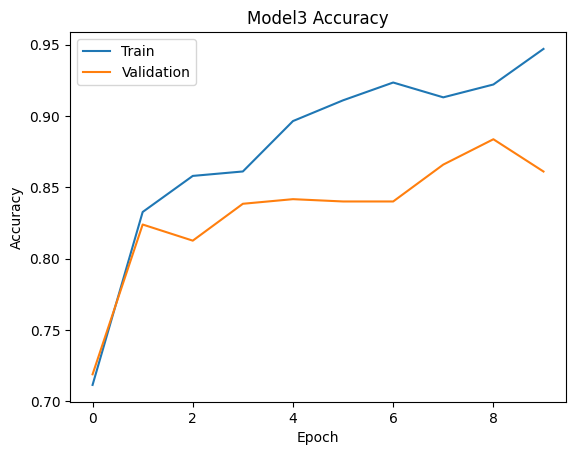

In [ ]:
# Plot the training accuracy over epochs from the history object.
plt.plot(history3.history['accuracy'])
# Plot the validation accuracy over epochs from the history object.
plt.plot(history3.history['val_accuracy'])

# Set the title of the plot.
plt.title('Model3 Accuracy')

# Set the label for the y-axis.
plt.ylabel('Accuracy')

# Set the label for the x-axis.
plt.xlabel('Epoch')

# Add a legend to the plot to identify the training and validation lines.
plt.legend(['Train', 'Validation'], loc='upper left')

# Display the generated plot.
plt.show()

91/91 ━━━━━━━━━━━━━━━━━━━━ 13s 129ms/step
Model 3 Training Performance:
   Accuracy    Recall  Precision  F1 Score
0  0.921025  0.921025   0.921025  0.921025
Model 3 Training Confusion Matrix:
91/91 ━━━━━━━━━━━━━━━━━━━━ 13s 130ms/step


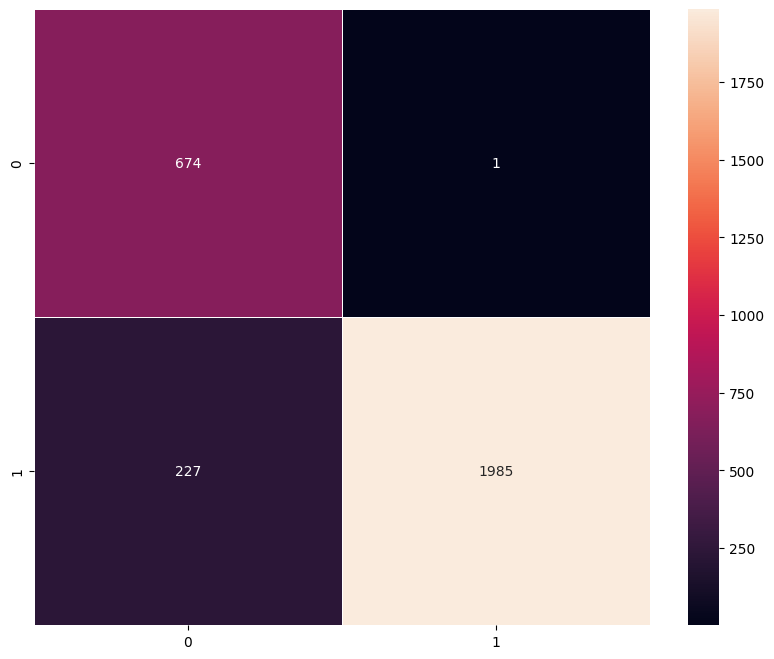

In [ ]:
# Evaluate the model on the Training set
model3_train_performance = model_performance_classification(model3, X_train, y_train)
print("Model 3 Training Performance:")
print(model3_train_performance)

# Plot the confusion matrix for the Training set
print("Model 3 Training Confusion Matrix:")
plot_confusion_matrix(model3, X_train, y_train)

Still model fails to identify true 'with helmet' cases in training set.

20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 131ms/step
Model 3 Validation Performance:
   Accuracy    Recall  Precision  F1 Score
0  0.861066  0.861066   0.861066  0.861066
Model 3 Validation Confusion Matrix:
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 135ms/step


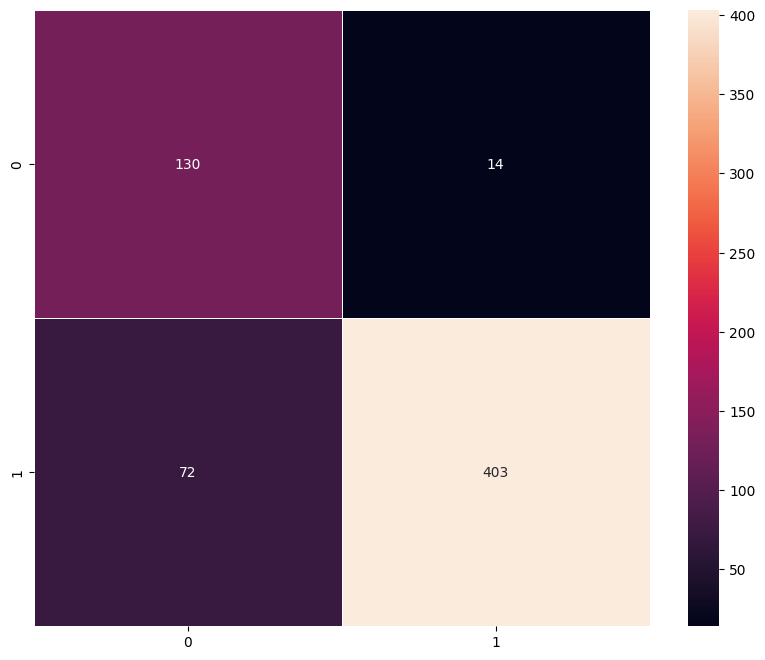

In [ ]:
# Evaluate the model on the validation set
model3_val_performance = model_performance_classification(model3, X_val, y_val)
print("Model 3 Validation Performance:")
print(model3_val_performance)

# Plot the confusion matrix for the validation set
print("Model 3 Validation Confusion Matrix:")
plot_confusion_matrix(model3, X_val, y_val)

Model's performance on validation set is quite similar to the Model 2. Adding extra layer is not improving the model's efficiency.

#### Visualizing the predictions

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step


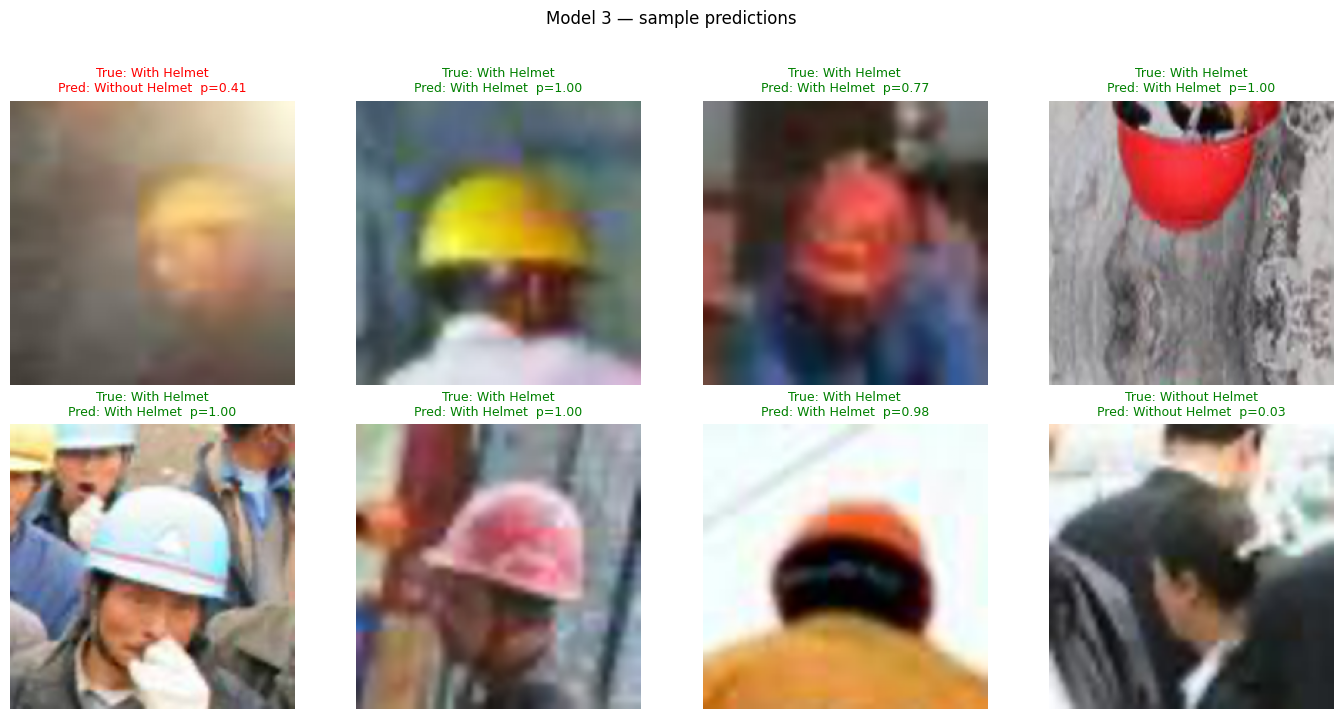

In [ ]:
# Visualize Model 3's predictions
rng = np.random.default_rng(42)
sample_idx = rng.choice(len(X_val), size=8, replace=False)
sample_probs = model3.predict(X_val[sample_idx]).ravel()
sample_preds = (sample_probs > 0.5).astype(int)
sample_true  = y_val.values.ravel()[sample_idx]

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for ax, i, prob, pred, true in zip(axes.ravel(), sample_idx, sample_probs, sample_preds, sample_true):
    ax.imshow(X_val[i])
    color = "green" if pred == true else "red"
    ax.set_title(
        f"True: {class_names[true]}\nPred: {class_names[pred]}  p={prob:.2f}",
        fontsize=9, color=color,
    )
    ax.axis("off")
plt.suptitle("Model 3 — sample predictions", y=1.02)
plt.tight_layout(); plt.show()


Simiklar to the previous model, this model also:

* Model predict false negetive for the first image of 'with helmet' as 'without helmet'
* Model's correctly predicts 'without helmet' here.
* Model correctly predicts other 'with helmet' images with high probability.

## Model 4: Transfer Learning with VGG-16 (Base + FFNN + Data Augmentation)

- In most of the real-world case studies, it is challenging to acquire a large number of images and then train CNNs.
- To overcome this problem, one approach we might consider is **Data Augmentation**.
- CNNs have the property of **translational invariance**, which means they can recognise an object even if its appearance shifts translationally in some way. - Taking this attribute into account, we can augment the images using the techniques listed below

    -  Horizontal Flip (should be set to True/False)
    -  Vertical Flip (should be set to True/False)
    -  Height Shift (should be between 0 and 1)
    -  Width Shift (should be between 0 and 1)
    -  Rotation (should be between 0 and 180)
    -  Shear (should be between 0 and 1)
    -  Zoom (should be between 0 and 1) etc.

Remember, **data augmentation should not be used in the validation/test data set**.

In [ ]:
tf.keras.backend.clear_session()

# Create an ImageDataGenerator for data augmentation
data_augmentor = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Prepare the base model for fine-tuning, similar to model3 setup
base_model_augmented = VGG16(weights='imagenet', include_top=False, input_shape=(200, 200, 3))
base_model_augmented.trainable = True

# Build model4 with the augmented base model and the classification head
model4 = Sequential([
    base_model_augmented,
    Flatten(),
    Dense(256, activation="relu"),
    Dropout(0.3),
    Dense(128, activation="relu"),
    Dropout(0.2),
    Dense(1, activation="sigmoid"),
], name="vgg16_ffnn_augmented")

# Compile model4 with a low learning rate for fine-tuning
model4.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
               loss='binary_crossentropy',
               metrics=['accuracy'])

# Print the summary of model4
print(model4.summary())

# Train model4 using the data augmentor
history4 = model4.fit(
    data_augmentor.flow(X_train, y_train, batch_size=32),
    validation_data=(X_val, y_val),
    epochs=10,
    class_weight=class_weight_dict,
    verbose=1
)

Model: "vgg16_ffnn_augmented"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 6, 6, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     4,718,848 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,466,561 (74.26 MB)

 Trainable params: 19,466,561 (74.26 MB)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/10
91/91 ━━━━━━━━━━━━━━━━━━━━ 70s 714ms/step - accuracy: 0.5615 - loss: 0.6864 - val_accuracy: 0.7932 - val_loss: 0.3784
Epoch 2/10
91/91 ━━━━━━━━━━━━━━━━━━━━ 64s 705ms/step - accuracy: 0.7662 - loss: 0.4447 - val_accuracy: 0.8966 - val_loss: 0.2195
Epoch 3/10
91/91 ━━━━━━━━━━━━━━━━━━━━ 64s 704ms/step - accuracy: 0.8660 - loss: 0.2990 - val_accuracy: 0.8562 - val_loss: 0.3267
Epoch 4/10
91/91 ━━━━━━━━━━━━━━━━━━━━ 65s 707ms/step - accuracy: 0.8975 - loss: 0.2389 - val_accuracy: 0.9160 - val_loss: 0.2126
Epoch 5/10
91/91 ━━━━━━━━━━━━━━━━━━━━ 64s 708ms/step - accuracy: 0.9037 - loss: 0.2164 - val_accuracy: 0.9192 - val_loss: 0.2077
Epoch 6/10
91/91 ━━━━━━━━━━━━━━━━━━━━ 64s 706ms/step - accuracy: 0.9158 - loss: 0.1832 - val_accuracy: 0.9338 - val_loss: 0.1779
Epoch 7/10
91/91 ━━━━━━━━━━━━━━━━━━━━ 65s 713ms/step - accuracy: 0.9151 - loss: 0.1977 - val_accuracy: 0.9128 - val_loss: 0.1755
Epoch 8/10
91/91 ━━━━━━━━━━━━━━━━━━━━ 63s 696ms/step - accuracy: 0.9124 - loss: 0.1986 - val

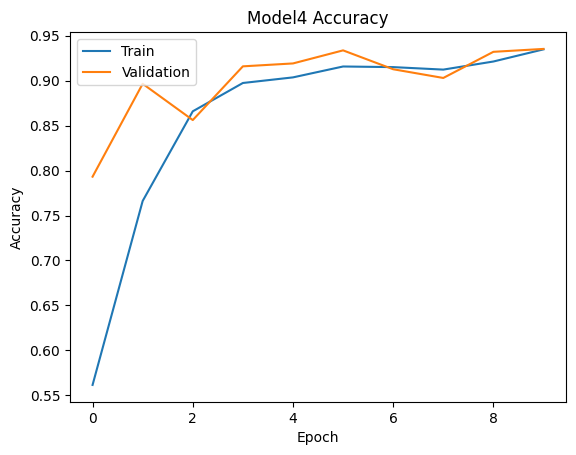

In [ ]:
# Plot the training accuracy over epochs from the history object.
plt.plot(history4.history['accuracy'])
# Plot the validation accuracy over epochs from the history object.
plt.plot(history4.history['val_accuracy'])

# Set the title of the plot.
plt.title('Model4 Accuracy')

# Set the label for the y-axis.
plt.ylabel('Accuracy')

# Set the label for the x-axis.
plt.xlabel('Epoch')

# Add a legend to the plot to identify the training and validation lines.
plt.legend(['Train', 'Validation'], loc='upper left')

# Display the generated plot.
plt.show()

91/91 ━━━━━━━━━━━━━━━━━━━━ 13s 133ms/step
Model 4 Training Performance:
   Accuracy    Recall  Precision  F1 Score
0  0.956702  0.956702   0.956702  0.956702
Model 4 Training Confusion Matrix:
91/91 ━━━━━━━━━━━━━━━━━━━━ 13s 129ms/step


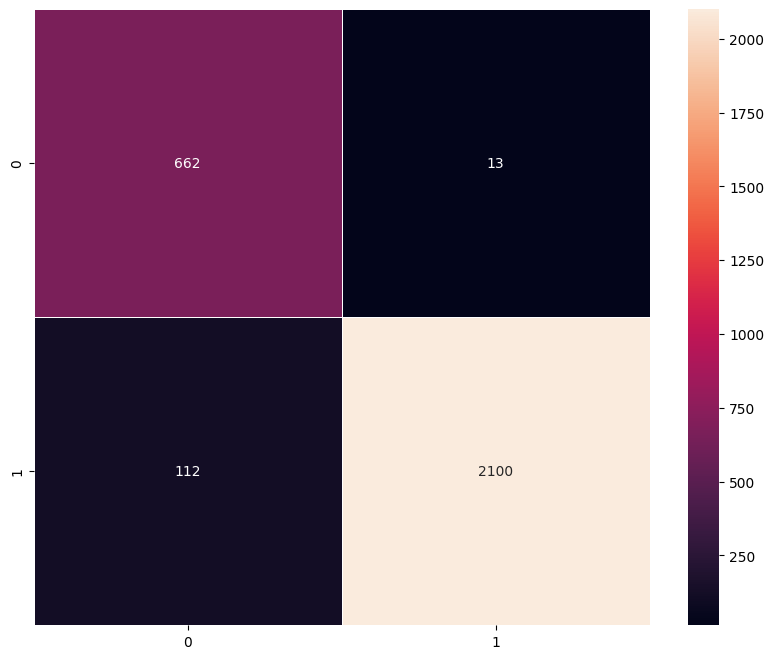

In [ ]:
# Evaluate the model on the Training set
model4_train_performance = model_performance_classification(model4, X_train, y_train)
print("Model 4 Training Performance:")
print(model4_train_performance)

# Plot the confusion matrix for the Training set
print("Model 4 Training Confusion Matrix:")
plot_confusion_matrix(model4, X_train, y_train)

Model performs better on finding True 'With Helmet' than the last 2 models, but lags on True 'without helmet' cases on training set. lets look at the validation set:

20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 132ms/step
Model 4 Validation Performance:
   Accuracy   Recall  Precision  F1 Score
0   0.93538  0.93538    0.93538   0.93538
Model 4 Validation Confusion Matrix:
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 134ms/step


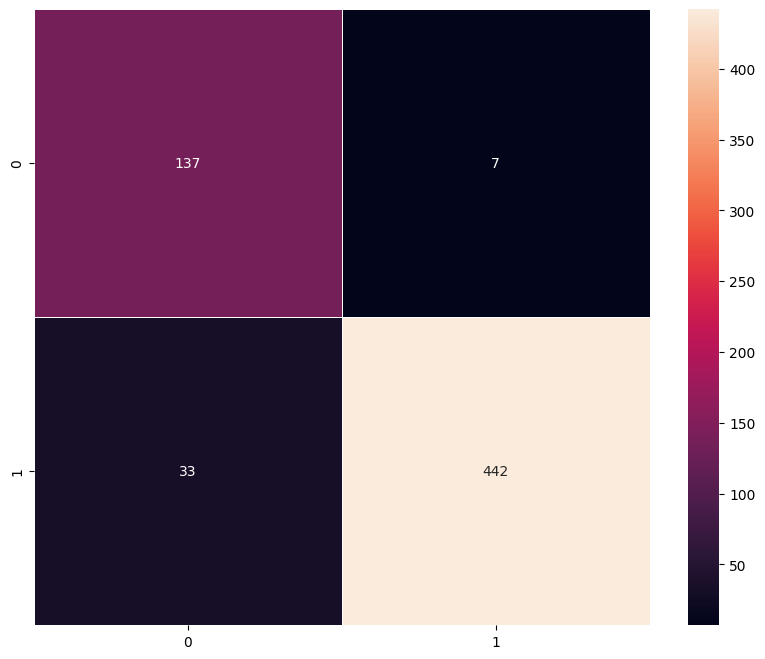

In [ ]:
# Evaluate the model on the validation set
model4_val_performance = model_performance_classification(model4, X_val, y_val)
print("Model 4 Validation Performance:")
print(model4_val_performance)

# Plot the confusion matrix for the validation set
print("Model 4 Validation Confusion Matrix:")
plot_confusion_matrix(model4, X_val, y_val)

Model improves on True 'with helmet' cases.

#### Visualizing the predictions

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step


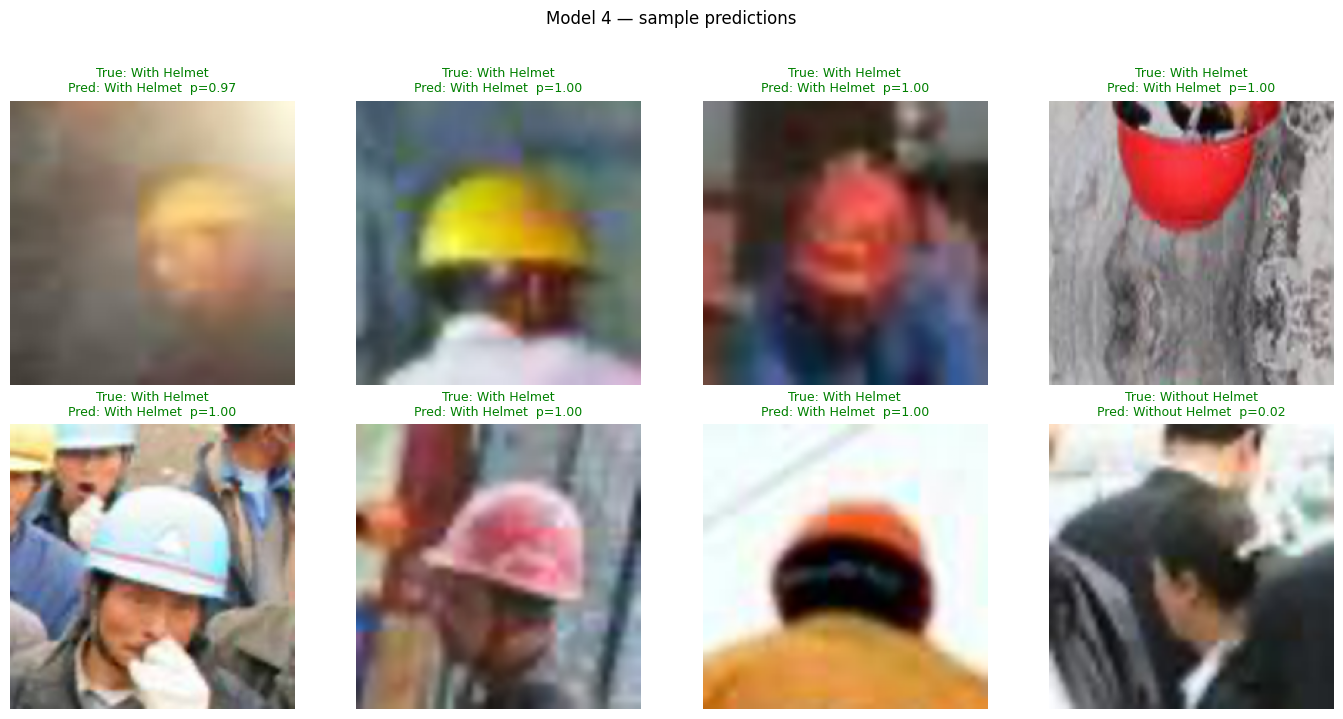

In [ ]:
# Visualize Model 4's predictions
rng = np.random.default_rng(42)
sample_idx = rng.choice(len(X_val), size=8, replace=False)
sample_probs = model4.predict(X_val[sample_idx]).ravel()
sample_preds = (sample_probs > 0.5).astype(int)
sample_true  = y_val.values.ravel()[sample_idx]

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for ax, i, prob, pred, true in zip(axes.ravel(), sample_idx, sample_probs, sample_preds, sample_true):
    ax.imshow(X_val[i])
    color = "green" if pred == true else "red"
    ax.set_title(
        f"True: {class_names[true]}\nPred: {class_names[pred]}  p={prob:.2f}",
        fontsize=9, color=color,
    )
    ax.axis("off")
plt.suptitle("Model 4 — sample predictions", y=1.02)
plt.tight_layout(); plt.show()


* Finally model predicts the first image as 'with helmet'!
* Model predictions for all these sample images are correct.

# **Model Performance Comparison and Final Model Selection**

Training performance comparison:
                               Accuracy  Recall  Precision  F1 Score
Model 1 — CNN from scratch       0.9993  0.9993     0.9993    0.9993
Model 2 — VGG-16 (base)          0.8933  0.8933     0.8933    0.8933
Model 3 — VGG-16 + FFNN          0.9210  0.9210     0.9210    0.9210
Model 4 — VGG-16 + FFNN + Aug    0.9567  0.9567     0.9567    0.9567


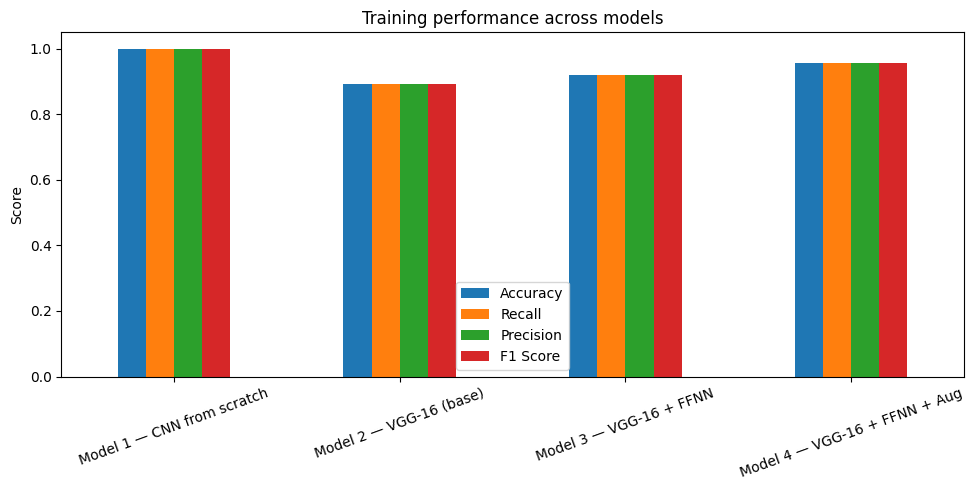


Best model on Training: Model 1 — CNN from scratch
Training accuracy: 0.9993


In [ ]:
# Compare all four models on the training set
comparison_train = pd.DataFrame({
    "Model 1 — CNN from scratch":          model1_train_performance.iloc[0],
    "Model 2 — VGG-16 (base)":             model2_train_performance.iloc[0],
    "Model 3 — VGG-16 + FFNN":             model3_train_performance.iloc[0],
    "Model 4 — VGG-16 + FFNN + Aug":       model4_train_performance.iloc[0],
}).T

print("Training performance comparison:")
print(comparison_train.round(4))

# Visual comparison
fig, ax = plt.subplots(figsize=(10, 5))
comparison_train.plot(kind="bar", ax=ax, rot=20)
ax.set_ylim(0, 1.05)
ax.set_title("Training performance across models")
ax.set_ylabel("Score")
plt.tight_layout(); plt.show()

# Pick the best model by traing accuracy
best_name = comparison_train["Accuracy"].idxmax()
print(f"\nBest model on Training: {best_name}")
print(f"Training accuracy: {comparison_train.loc[best_name, 'Accuracy']:.4f}")

Validation performance comparison:
                               Accuracy  Recall  Precision  F1 Score
Model 1 — CNN from scratch       0.9241  0.9241     0.9241    0.9241
Model 2 — VGG-16 (base)          0.8611  0.8611     0.8611    0.8611
Model 3 — VGG-16 + FFNN          0.8611  0.8611     0.8611    0.8611
Model 4 — VGG-16 + FFNN + Aug    0.9354  0.9354     0.9354    0.9354


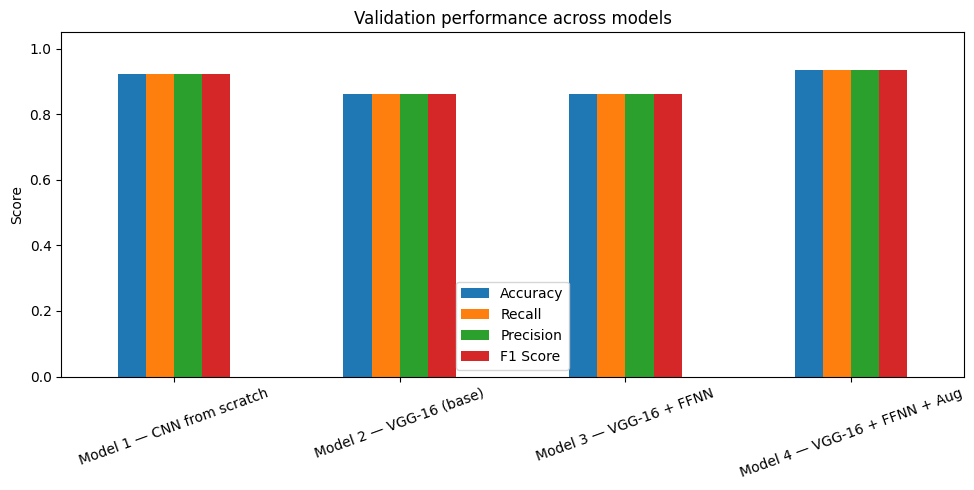


Best model on validation: Model 4 — VGG-16 + FFNN + Aug
Validation accuracy: 0.9354


In [ ]:
# Compare all four models on the validation set
comparison_validation = pd.DataFrame({
    "Model 1 — CNN from scratch":          model1_val_performance.iloc[0],
    "Model 2 — VGG-16 (base)":             model2_val_performance.iloc[0],
    "Model 3 — VGG-16 + FFNN":             model3_val_performance.iloc[0],
    "Model 4 — VGG-16 + FFNN + Aug":       model4_val_performance.iloc[0],
}).T

print("Validation performance comparison:")
print(comparison_validation.round(4))

# Visual comparison
fig, ax = plt.subplots(figsize=(10, 5))
comparison_validation.plot(kind="bar", ax=ax, rot=20)
ax.set_ylim(0, 1.05)
ax.set_title("Validation performance across models")
ax.set_ylabel("Score")
plt.tight_layout(); plt.show()

# Pick the best model by validation accuracy
best_name = comparison_validation["Accuracy"].idxmax()
print(f"\nBest model on validation: {best_name}")
print(f"Validation accuracy: {comparison_validation.loc[best_name, 'Accuracy']:.4f}")

In [ ]:
comparison = comparison_train - comparison_validation
print("Difference between training and validation performance:")
print(comparison.round(4))

Difference between training and validation performance:
                               Accuracy  Recall  Precision  F1 Score
Model 1 — CNN from scratch       0.0752  0.0752     0.0752    0.0752
Model 2 — VGG-16 (base)          0.0322  0.0322     0.0322    0.0322
Model 3 — VGG-16 + FFNN          0.0600  0.0600     0.0600    0.0600
Model 4 — VGG-16 + FFNN + Aug    0.0213  0.0213     0.0213    0.0213


In [ ]:
summary_display = comparison.copy()
summary_display.index.name = 'Model Architecture'
# Highlighting the best score for each metric
display(summary_display.style.highlight_max(color='darkgreen', axis=0).format('{:.4f}'))

,Accuracy,Recall,Precision,F1 Score
Model Architecture,,,,
Model 1 — CNN from scratch,0.0752,0.0752,0.0752,0.0752
Model 2 — VGG-16 (base),0.0322,0.0322,0.0322,0.0322
Model 3 — VGG-16 + FFNN,0.0600,0.0600,0.0600,0.0600
Model 4 — VGG-16 + FFNN + Aug,0.0213,0.0213,0.0213,0.0213


## Test Performance

20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 134ms/step
Model 4 Test Performance:
   Accuracy    Recall  Precision  F1 Score
0  0.938611  0.938611   0.938611  0.938611
Model 4 Test Confusion Matrix:
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 135ms/step


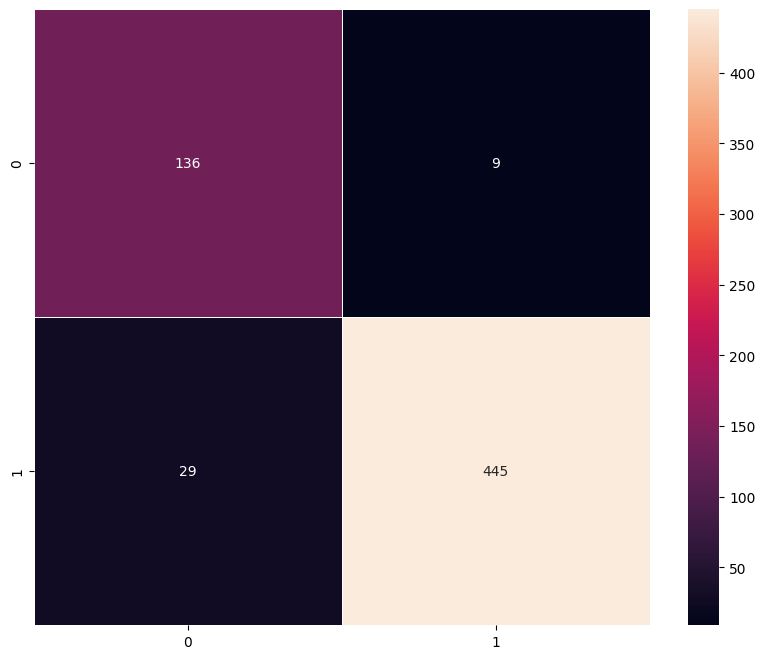

In [ ]:
#Use the model4 to to test unseen test data set
model4_test_performance = model_performance_classification(model4, X_test, y_test)
print("Model 4 Test Performance:")
print(model4_test_performance)

print("Model 4 Test Confusion Matrix:")
plot_confusion_matrix(model4, X_test, y_test)

# **Actionable Insights & Recommendations**

-
-

<font size=5 color='blue'>Power Ahead!</font>
___